# Landsat 8: od danych do mapy WWW

**Laboratorium: 90 minut.** Scena: 7 sierpnia 2013 r., Kraków i okolice. Przetwarzanie w Pythonie, bez QGIS.

Po zajęciach potrafisz obliczyć NDVI, NDBI i MNDWI, sprawdzić georeferencję i jakość danych oraz opublikować wynik przez SSH/SCP.

**Przed zajęciami:** Python 3.12, instalacja `requirements.txt`, aktywne konto UNIX AGH i sprawdzone połączenie przez sieć AGH/VPN. Dokładne polecenia są w `docs/polecenia_iterm.md`.

| Minuty | Etap |
|---|---|
| 0–10 | Środowisko |
| 10–25 | Dane i georeferencja |
| 25–40 | Skalowanie i maskowanie |
| 40–55 | Wskaźniki i interpretacja |
| 55–70 | Eksport i mapa lokalna |
| 70–85 | SSH/SCP |
| 85–90 | Kontrola i oddanie |

Wybierz kernel **Python (Landsat LAB)**. Uruchamiaj komórki po kolei przez Shift+Enter. „Restart Kernel and Run All Cells” odtwarza lokalne wyniki; nie publikuje niczego na serwerze.

## 1. Środowisko i ścieżki • 0–10 min

Notatnik wyszukuje katalog pakietu w bieżącym katalogu lub jego rodzicach. Dzięki temu działa po przeniesieniu całego `LABOLATORIUM`. Dane wejściowe mają około 23 MB. Nie pobieramy sceny podczas zajęć.

In [1]:
from pathlib import Path
import sys, json, time
import numpy as np
import rasterio
from IPython.display import display, Image, Markdown

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "src/landsat_lab.py").exists()), None)
assert ROOT is not None, "Uruchom Jupyter wewnątrz katalogu LABOLATORIUM."
sys.path.insert(0, str(ROOT / "src"))
from landsat_lab import (load_scene, normalized_difference, calculate_indices,
                         export_results, stretch_rgb, INDEX_BANDS)
import matplotlib.pyplot as plt
%matplotlib inline
DATA = ROOT / "data"
OUT = ROOT / "outputs"
print("Pakiet:", ROOT)
print("Python:", sys.version.split()[0], "Rasterio:", rasterio.__version__)
assert (DATA / "aoi.geojson").is_file()
assert len(list((DATA / "scene").glob("*.tif"))) == 7
print("Dane wejściowe kompletne.")

Matplotlib is building the font cache; this may take a moment.


Pakiet: C:\Users\DELL\OneDrive\Desktop\studia\Semestr_7\piacdpibmsi\LABORATORIUM
Python: 3.12.10 Rasterio: 1.5.1
Dane wejściowe kompletne.


**Punkt kontrolny:** komunikat „Dane wejściowe kompletne”. Jeśli import się nie powiedzie, sprawdź kernel, zamiast instalować biblioteki do przypadkowego interpretera.

## 2. Dane, kanały i układ współrzędnych • 10–25 min

Wykorzystujemy historyczny produkt **Landsat Collection 1 Surface Reflectance**. Paczka obejmuje B2–B6, `pixel_qa`, `radsat_qa` i XML. To prostokątny wycinek oryginalnej sceny, bez zmiany wartości DN i rozdzielczości 30 m. Metadane XML opisują pełną scenę; wymiary i transformację wycinka czytamy z GeoTIFF.

| Kanał | Znaczenie | Zastosowanie |
|---|---|---|
| B2 | niebieski | RGB |
| B3 | zielony | RGB i MNDWI |
| B4 | czerwony | RGB i NDVI |
| B5 | bliska podczerwień (NIR) | NDVI i NDBI |
| B6 | krótkofalowa podczerwień (SWIR1) | NDBI i MNDWI |

Granica pochodzi z istniejącego projektu. Oryginalny SHP nie zawierał PRJ ani DBF. Układ EPSG:32634 odtworzono przez zgodność z istniejącymi rastrami przyciętymi; założenie opisano w `data/manifest.json`. Dostarczony GeoJSON ma współrzędne geograficzne EPSG:4326. Nie traktujemy tej granicy jako nowo zweryfikowanej granicy administracyjnej.

In [2]:
scene = load_scene(DATA)
meta = scene["metadata"]
profile = scene["profile"]
print("Scena:", meta["product"])
print("Data:", meta["date"])
print("Wymiary:", profile["height"], "x", profile["width"])
print("CRS:", profile["crs"])
print("Rozmiar piksela [m]:", profile["transform"].a, -profile["transform"].e)
print("Granica:", json.loads((DATA / "manifest.json").read_text())["boundary_crs_assumption"])

Scena: LC08_L1TP_188025_20130807_20170503_01_T1
Data: 2013-08-07
Wymiary: 1583 x 1982
CRS: EPSG:32634
Rozmiar piksela [m]: 30.0 30.0
Granica: Oryginalny SHP nie ma PRJ ani DBF. EPSG:32634 odtworzono przez zgodnoĹ›Ä‡ zasiÄ™gu ze znajdujÄ…cymi siÄ™ w projekcie rastrami clipped. GeoJSON zapisano w EPSG:4326. Nie jest to nowo pozyskana oficjalna granica administracyjna.


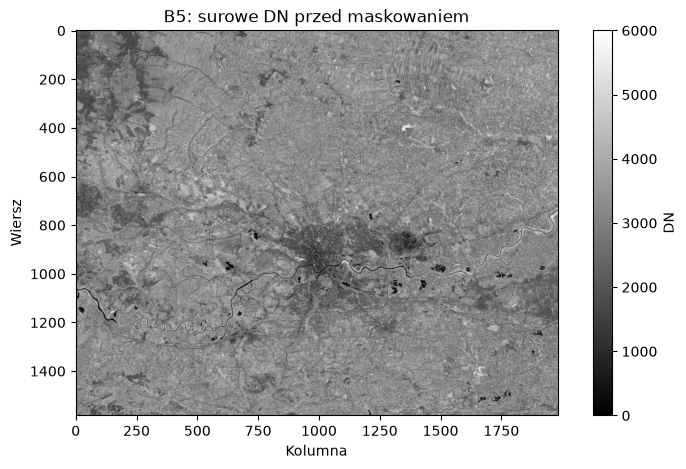

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
a = scene["raw"]["sr_band5"].astype(float)
a[a == meta["bands"]["sr_band5"]["fill"]] = np.nan
im = ax.imshow(a, cmap="gray", vmin=0, vmax=6000)
ax.set(title="B5: surowe DN przed maskowaniem", xlabel="Kolumna", ylabel="Wiersz")
fig.colorbar(im, ax=ax, label="DN")
display(fig)
plt.close(fig)

**Pytanie:** dlaczego nie wystarczy przypisać wektorowi CRS rastra? Przypisanie określa znaczenie liczb; reprojekcja przelicza współrzędne. Funkcja `load_scene` wykonuje `transform_geom` z EPSG:4326 do CRS rastra, a następnie tworzy maskę granicy.

**Punkt kontrolny:** wycinek 1583 × 1982 piksele, EPSG:32634 i piksel 30 × 30 m.

## 3. Reflektancja i jakość danych • 25–40 min

Reflektancja = DN × skala + offset. Dla naszej sceny XML podaje skalę 0.0001 i brak offsetu (przyjmujemy 0). To nie jest informacja o „maksymalnej wartości piksela”. Dla innych produktów parametry mogą być inne. Ten kod celowo odrzuca Collection 2 zamiast używać błędnej maski QA.

NoData nie oznacza wartości zero. Ujemne i zerowe wyniki mogą być poprawnymi wynikami obliczeń. NaN oznacza brak ważnej obserwacji.

Polityka QA w ćwiczeniu: odrzucamy fill, cień chmur, śnieg, chmury, przesłonięcie terenu, wysoką pewność chmur/cirrus oraz nasycenie użytych kanałów. Flaga wody nie jest powodem odrzucenia. Używamy wspólnej maski dla B2–B6, aby porównywać wskaźniki na tych samych pikselach.

In [4]:
b5 = meta["bands"]["sr_band5"]
print("Skala:", b5["scale"], "Offset:", b5["offset"], "Fill:", b5["fill"])
print("DN 6000 daje reflektancję:", 6000 * b5["scale"] + b5["offset"])
inside_count = int(scene["inside"].sum())
valid_count = int(scene["valid"].sum())
print("W granicy:", inside_count)
print("Ważne po wszystkich maskach:", valid_count)
print("Odrzucone w granicy [%]:", round(100 * (1 - valid_count / inside_count), 2))
print("Bit wody w wartości 4:", bool(4 & (1 << 2)))

Skala: 0.0001 Offset: 0.0 Fill: -9999.0
DN 6000 daje reflektancję: 0.6
W granicy: 1729364
Ważne po wszystkich maskach: 1729266
Odrzucone w granicy [%]: 0.01
Bit wody w wartości 4: True


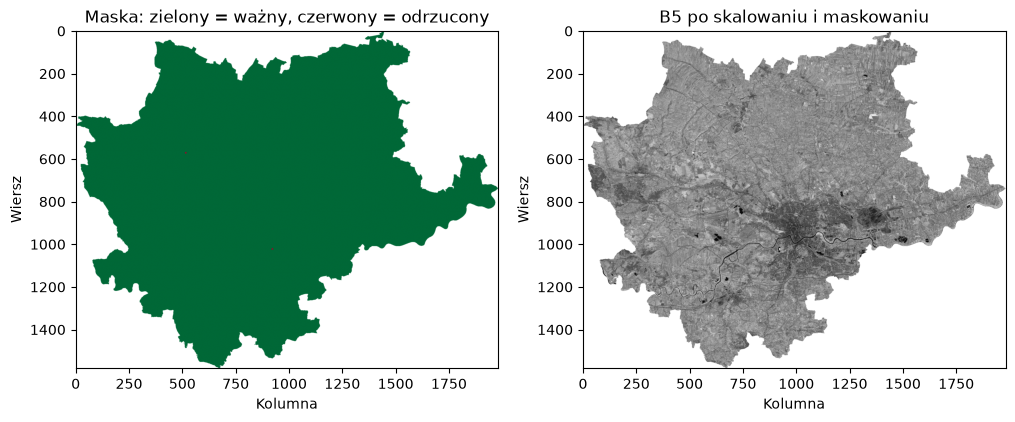

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.where(scene["inside"], scene["valid"], np.nan), cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_title("Maska: zielony = ważny, czerwony = odrzucony")
axes[1].imshow(scene["reflectance"][5], cmap="gray", vmin=0, vmax=0.6)
axes[1].set_title("B5 po skalowaniu i maskowaniu")
for ax in axes: ax.set(xlabel="Kolumna", ylabel="Wiersz")
display(fig)
plt.close(fig)

**Ćwiczenie:** wyjaśnij, dlaczego bit wody powinien pozostać w zbiorze ważnych pikseli. Sprawdź kod `quality_mask` w `src/landsat_lab.py`. Maskę QA dopasowujemy do produktu; układ bitów C1 nie jest układem QA_PIXEL z C2.

## 4. NDVI, NDBI i MNDWI • 40–55 min

$$NDVI = \frac{B5-B4}{B5+B4},\quad NDBI = \frac{B6-B5}{B6+B5},\quad MNDWI = \frac{B3-B6}{B3+B6}$$

W poprzedniej wersji projektu wzór z B3 i B6 nosił nazwę NDWI. Tutaj używamy precyzyjniejszej nazwy **MNDWI**. NDWI McFeetersa używa kanału zielonego i NIR.

Przykład dydaktyczny, nie pomiar z mapy: NIR = 0.6 i RED = 0.2 dają NDVI = 0.5. Dla równych, niezerowych kanałów otrzymamy 0. Dla dwóch zer wynik jest nieokreślony.

In [6]:
# Najważniejsze obliczenie pokazane jawnie.
nir = scene["reflectance"][5]
red = scene["reflectance"][4]
denominator = nir + red
ndvi = np.full(nir.shape, np.nan, dtype="float32")
np.divide(nir - red, denominator, out=ndvi,
          where=np.isfinite(nir) & np.isfinite(red) & (np.abs(denominator) > 1e-6))

indices = calculate_indices(scene["reflectance"])
np.testing.assert_allclose(ndvi, indices["NDVI"], equal_nan=True)
print("Przykład NDVI:", normalized_difference(np.array([.6, .2, 0]), np.array([.2, .2, 0])))
print("Kanały wskaźników:", INDEX_BANDS)

Przykład NDVI: [0.50000006 0.                nan]
Kanały wskaźników: {'NDVI': (5, 4), 'NDBI': (6, 5), 'MNDWI': (3, 6)}


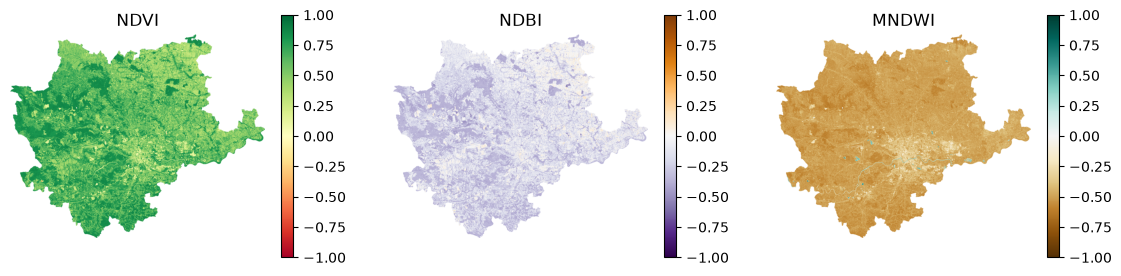

NDVI średnia 0.6179 mediana 0.6402 poza [-1,1] 3
NDBI średnia -0.1905 mediana -0.1909 poza [-1,1] 2
MNDWI średnia -0.4896 mediana -0.5045 poza [-1,1] 0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, name, cmap in zip(axes, indices, ["RdYlGn", "PuOr_r", "BrBG"]):
    im = ax.imshow(indices[name], cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(name)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=.7)
display(fig)
plt.close(fig)
for name, a in indices.items():
    values = a[np.isfinite(a)]
    print(name, "średnia", round(float(values.mean()), 4), "mediana", round(float(np.median(values)), 4),
          "poza [-1,1]", int((np.abs(values) > 1).sum()))

**Interpretacja:** wysokie NDVI zwykle wspiera rozpoznanie roślinności. Dodatni NDBI może występować także na odsłoniętej glebie. Dodatni MNDWI jest wskazówką obecności wody, a nie automatycznym dowodem. Wskaźniki nie są wytrenowanym modelem klasyfikacji.

Wartości spoza [-1, 1] mogą wystąpić przy ujemnej reflektancji. Sprawdzamy ich liczbę i zachowujemy w GeoTIFF. Ograniczenie kolorów na mapie nie zmienia wyników liczbowych.

**Ćwiczenie obowiązkowe:** porównaj mapy z RGB. Wskaż po jednym obszarze roślinności, wody i możliwej zabudowy. Zapisz trzy wnioski w ostatniej komórce. Nie interpretuj sceny z 2013 r. jako aktualnego stanu miasta.

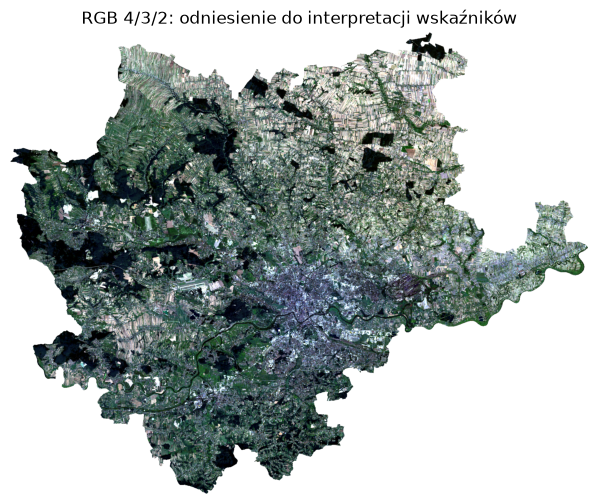

Udział ważnych pikseli z NDVI > 0.5: 72.01%


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(stretch_rgb(scene["reflectance"]))
ax.set_title("RGB 4/3/2: odniesienie do interpretacji wskaźników")
ax.set_axis_off()
display(fig)
plt.close(fig)
# Próg służy eksperymentowi; nie jest zweryfikowaną klasyfikacją.
threshold = 0.5
share = np.count_nonzero(indices["NDVI"] > threshold) / np.isfinite(indices["NDVI"]).sum()
print(f"Udział ważnych pikseli z NDVI > {threshold}: {100 * share:.2f}%")

## 5. Eksport i mapa lokalna • 55–70 min

GeoTIFF `NDVI.tif` przechowuje wartości float32, georeferencję i NoData = -9999. `NDVI_display.tif` przechowuje kolory RGBA. Kanał alfa nadaje przezroczystość brakom danych.

Python tworzy kafelki PNG 256 × 256 w EPSG:3857, w schemacie **XYZ** (`z/x/y.png`, y rośnie na południe). Leaflet otrzymuje `tms=False`. Reprojekcja dotyczy prezentacji; obliczenia wykonaliśmy na oryginalnej siatce. Kafelki stosują nearest neighbour, żeby nie mieszać kolorów na granicy NoData.

Zakres zoomów 9–12 ogranicza czas przetwarzania i rozmiar publikacji. Powiększenie w przeglądarce do 17 nie dodaje informacji do pikseli źródłowych.

In [9]:
start = time.perf_counter()
summary = export_results(scene, indices, OUT, minzoom=9, maxzoom=12)
print("Eksport [s]:", round(time.perf_counter() - start, 1))
print("Kafelki:", summary["tiles"])
print("Strona:", OUT / "site/index.html")
with rasterio.open(OUT / "rasters/NDVI.tif") as src:
    restored = src.read(1, masked=True).filled(np.nan)
    np.testing.assert_allclose(restored, ndvi, equal_nan=True)
    assert src.crs == profile["crs"] and src.transform == profile["transform"]
    print("Kontrola GeoTIFF: wartości i georeferencja poprawne.")

Eksport [s]: 24.2
Kafelki: {'RGB': 128, 'NDVI': 128, 'NDBI': 128, 'MNDWI': 128}
Strona: C:\Users\DELL\OneDrive\Desktop\studia\Semestr_7\piacdpibmsi\LABORATORIUM\outputs\site\index.html
Kontrola GeoTIFF: wartości i georeferencja poprawne.


W osobnym iTerm, z katalogu LABOLATORIUM:

```bash
source .venv/bin/activate
python -m http.server 8000 --bind 127.0.0.1 --directory outputs/site
```

Otwórz **http://127.0.0.1:8000/**. Sprawdź wszystkie cztery warstwy, legendę i suwak. Nie otwieraj HTML przez `file://`. Serwer pozostaw uruchomiony, a publikację wykonuj w kolejnym terminalu.

## 6. Publikacja SSH/SCP • 70–85 min

Poniższa instrukcja jest pełną instrukcją terminala. **Bloki bash wykonujesz w iTerm, nie w Pythonie.** Publikacja jest osobnym krokiem, wymagającym Twojego logowania. Prowadzący i studenci mają różne hosty SSH i adresy stron.

#### 6.3.1. Wybór konta i sprawdzenie SSH

Według [CRI AGH](https://cri.agh.edu.pl/uslugi/konta-unix) SSH/SCP wymaga sieci AGH lub VPN. Serwer studentów to `student.agh.edu.pl`, a pracowników i doktorantów `galaxy.agh.edu.pl`. Strony na serwerze student są dostępne w sieci uczelni/VPN, nie w całym internecie.

W **nowym lokalnym terminalu**, w katalogu LABOLATORIUM, wybierz JEDEN wariant. Używaj loginu UNIX, bez części `@...`.

**Student:**

```bash
read "AGH_LOGIN?Podaj login UNIX AGH: "
AGH_HOST="student.agh.edu.pl"
AGH_WEB="https://student.agh.edu.pl"
```

`read "zmienna?tekst"` jest składnią zsh w iTerm/macOS. W bash zamiast pierwszej linii użyj `read -r -p "Podaj login UNIX AGH: " AGH_LOGIN`.

**Prowadzący, konto odpowiadające stronie home.agh.edu.pl/~owerko:**

```bash
AGH_LOGIN="owerko"
AGH_HOST="galaxy.agh.edu.pl"
AGH_WEB="https://home.agh.edu.pl"
```

Następnie w obu wariantach:

```bash
ssh "${AGH_LOGIN}@${AGH_HOST}"
```

Przy pierwszym połączeniu zweryfikuj odcisk klucza hosta według informacji administratora. Nie wyłączaj sprawdzania kluczy SSH. Terminal nie pokazuje wpisywanych znaków hasła.

Poniższe trzy polecenia wykonujesz już **na serwerze**:

```bash
pwd
ls -ld "$HOME" public_html
exit
```

Brak `public_html` przy pierwszym logowaniu jest normalny. `exit` kończy sesję zdalną. Kolejne polecenia wykonujesz ponownie lokalnie. Zmienne AGH ustawione lokalnie pozostają dostępne.

#### 6.3.2. Przygotowanie osobnego katalogu publikacji

Publikujemy w nowym podkatalogu z datą i godziną. Główna strona `~/public_html/index.html` pozostaje nietknięta. Nazwa powstaje automatycznie i zawiera wyłącznie bezpieczne znaki.

```bash
AGH_FOLDER="landsat-$(date +%Y%m%d-%H%M%S)"
ssh "${AGH_LOGIN}@${AGH_HOST}" "mkdir -p public_html/${AGH_FOLDER} && chmod 755 public_html public_html/${AGH_FOLDER}"
```

### 6.3. Przesłanie CAŁEJ strony przez SCP

Polecenie wykonaj lokalnie z katalogu `LABOLATORIUM`. Końcówka `/.` oznacza zawartość katalogu strony.

```bash
scp -r outputs/site/. "${AGH_LOGIN}@${AGH_HOST}:public_html/${AGH_FOLDER}/"
ssh "${AGH_LOGIN}@${AGH_HOST}" "find public_html/${AGH_FOLDER} -type d -exec chmod 755 {} + && find public_html/${AGH_FOLDER} -type f -exec chmod 644 {} +"
```

Na serwer trafiają `index.html`, `vendor`, `tiles`, `aoi.geojson` i `summary.json`. Nie przesyłaj `.venv`, surowych danych ani całego projektu. Ponowne SCP do tego samego katalogu aktualizuje znajdujące się tam pliki.

### 6.4. Weryfikacja publikacji

```bash
ssh "${AGH_LOGIN}@${AGH_HOST}" "test -f public_html/${AGH_FOLDER}/index.html && test -f public_html/${AGH_FOLDER}/vendor/leaflet.js && find public_html/${AGH_FOLDER}/tiles -name '*.png' | wc -l"
AGH_URL="${AGH_WEB}/~${AGH_LOGIN}/${AGH_FOLDER}/"
printf '%s\n' "$AGH_URL"
curl -I "$AGH_URL"
open "$AGH_URL"
```

`open` jest poleceniem macOS. Na innym systemie skopiuj wypisany adres do przeglądarki. Oczekuj odpowiedzi HTTP 200 (lub przekierowania prowadzącego do 200), działających warstw i kompletnej legendy. Sama odpowiedź 200 dla HTML nie potwierdza obecności kafelków.

Gdy pojawi się 403, sprawdź prawa katalogów i plików. Jeśli serwer wymaga prawa przejścia przez katalog domowy, po sprawdzeniu ustawień konta możesz nadać wyłącznie to prawo: `ssh "${AGH_LOGIN}@${AGH_HOST}" 'chmod o+x "$HOME"'`. Nie stosuj `chmod -R 777`.



## 7. Kontrola i oddanie • 85–90 min

Sprawdź, że strona działa po wejściu pod zdalny adres, a nie tylko lokalnie. Przełącz wszystkie warstwy. Jeśli zabrakło dostępu do konta, zachowaj kompletny katalog `outputs/site` i dokończ publikację po odzyskaniu dostępu. Nie opisuj wyniku lokalnego jako opublikowanego.

**Oddaj:** notatnik z wynikami, rzeczywisty URL i trzy wnioski. Ocena: poprawność obliczeń i QA (4 pkt), mapa z legendą (2 pkt), publikacja (2 pkt), interpretacja (2 pkt).

### Moje wyniki

- Adres opublikowanej mapy: **wpisz po wykonaniu SCP**.
- NDVI: **opisz wskazany obszar i obserwację**.
- NDBI: **opisz obserwację i możliwe pomylenie zabudowy z glebą**.
- MNDWI: **opisz wskazany zbiornik/ciek lub wyjaśnij niepewność wyniku**.
- Data obserwacji: 2013-08-07. Data wykonania ćwiczenia: **uzupełnij**.

## Rozszerzenia po zajęciach

1. Zmień próg NDVI z 0.5 na 0.3 i porównaj udziały. Dlaczego nie są one zweryfikowanym udziałem powierzchni roślinności?
2. Oblicz NDWI = (B3 − B5)/(B3 + B5) i porównaj z MNDWI.
3. Wygeneruj mapę do osobnego katalogu z `maxzoom=11`. Porównaj rozmiar danych i czytelność.

## Źródła i pochodzenie

- Dane i XML: USGS/EROS, istniejący projekt NASA/Landsat8. Pierwotny kod projektu: credit S. Moliński.
- [USGS: NDVI](https://www.usgs.gov/landsat-missions/landsat-normalized-difference-vegetation-index).
- [USGS: skala i offset produktów Landsat](https://www.usgs.gov/faqs/how-do-i-use-a-scale-factor-landsat-level-2-science-products).
- Xu (2006), MNDWI: DOI [10.1080/01431160600589179](https://doi.org/10.1080/01431160600589179).
- Zha, Gao, Ni (2003), NDBI: DOI [10.1080/01431160210144570](https://doi.org/10.1080/01431160210144570).
- [Rasterio: reprojekcja](https://rasterio.readthedocs.io/en/stable/topics/reproject.html).
- [Leaflet 1.9.4](https://leafletjs.com/reference.html).
- [CRI AGH: konta UNIX](https://cri.agh.edu.pl/uslugi/konta-unix), sprawdzono 30.09.2026.

Maskę QA i parametry skalowania dla paczki odczytano z dołączonego XML. Brakujące metadane granicy i przyjęte założenia opisuje `data/manifest.json`.